In [1]:
# Set system path

from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p  # fallback


repo_root = find_repo_root()
print(repo_root)

# This repo uses a "src layout" (the Python package lives in <repo>/src/qlsas),
# but the repo is not installed as a package. Add <repo>/src to sys.path.
src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

# Also add the repo root so you can import top-level modules like
# `linear_systems_problems.random_matrix_generator`.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

/Users/adrianharkness/QCOL_COPT/HHL/QLSAs


In [2]:
# Import QLSAs modules

from qlsas.algorithms.hhl.hhl import HHL
from qlsas.data_loader import StatePrep
from qlsas.transpiler import Transpiler
from qlsas.executer import Executer
from qlsas.post_processor import Post_Processor
from qlsas.solver import QuantumLinearSolver
from qlsas.refiner import Refiner

# Import other modules
import contextlib
import sys
import numpy as np
import scipy as sp
import math
import matplotlib.pyplot as plt
import scipy.sparse as sps
from copy import deepcopy
np.set_printoptions(edgeitems=30, linewidth=100000)

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

%config InlineBackend.figure_format = "retina"

# **Problem Data**


In [3]:
def setup_fba_problem():
    reaction_names = [
        'GLCup', 'HK', 'PGI', 'PFK', 'ALDO', 'TPI', 'GAPDH', 'PGK', 'PGM', 'ENO',
        'PK', 'PDH', 'CS', 'ICDH', 'AKGDH', 'SDH', 'MDH', 'PC', 'BIOMASS'
    ]

    internal_metabolites = [
        'Glc_i', 'G6P', 'F6P', 'F16BP', 'DHAP', 'G3P', 'BPG', '3PG', '2PG',
        'PEP', 'Pyr', 'AcCoA', 'OAA', 'Cit', 'aKG', 'Suc', 'Mal'
    ]

    S = np.array([
        # GLCup HK  PGI PFK ALDO TPI GAPDH PGK PGM ENO PK  PDH CS  ACO ICDH AKGDH SCS SDH FUM MDH PC  BIOMASS
        [ 1,   -1,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0,  0     ], # Glc_i
        [ 0,    1, -1,  0,  0,   0,  0,    0,  0,  0,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0, -0.205 ], # G6P
        [ 0,    0,  1, -1,  0,   0,  0,    0,  0,  0,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0, -0.071 ], # F6P
        [ 0,    0,  0,  1, -1,   0,  0,    0,  0,  0,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0,  0     ], # F16BP
        [ 0,    0,  0,  0,  1,  -1,  0,    0,  0,  0,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0,  0     ], # DHAP
        [ 0,    0,  0,  0,  1,   1, -1,    0,  0,  0,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0, -0.129 ], # G3P
        [ 0,    0,  0,  0,  0,   0,  1,   -1,  0,  0,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0,  0     ], # BPG
        [ 0,    0,  0,  0,  0,   0,  0,    1, -1,  0,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0, -0.519 ], # 3PG
        [ 0,    0,  0,  0,  0,   0,  0,    0,  1, -1,  0,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0,  0     ], # 2PG
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  1, -1,  0,  0,  0,  0,   0,    0,  0,  0,  0,  0, -0.361 ], # PEP
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  1, -1,  0,  0,  0,   0,    0,  0,  0,  0, -1, -2.833 ], # Pyr
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  1, -1,  0,  0,   0,    0,  0,  0,  0,  0, -3.748 ], # AcCoA
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0, -1,  0,  0,   0,    0,  0,  0,  1,  1, -0.161 ], # OAA
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0,  1, -1,  0,   0,    0,  0,  0,  0,  0,  0     ], # Cit
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0,  0,  1, -1,   0,    0,  0,  0,  0,  0,  0     ], # Isocit
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0,  0,  0,  1,  -1,    0,  0,  0,  0,  0, -0.496 ], # aKG
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0,  0,  0,  0,   1,   -1,  0,  0,  0,  0,  0     ], # SucCoA
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0,  0,  0,  0,   0,    1, -1,  0,  0,  0,  0     ], # Suc
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0,  0,  0,  0,   0,    0,  1, -1,  0,  0,  0     ], # Fum
        [ 0,    0,  0,  0,  0,   0,  0,    0,  0,  0,  0,  0,  0,  0,  0,   0,    0,  0,  1, -1,  0,  0     ]  # Mal
    ])

    b = np.zeros(20)

    C = np.zeros(22)
    C[21] = 1  # Maximize BIOMASS reaction

    l = np.array([0, 0, -10, 0, -10, -10, -10, -10, -10, -10,
                  0, 0, 0, -10, 0, 0, -10, 0,-10, -10, 0, 0])

    u = np.array([10, 50, 1000, 100, 1000, 1000, 1000, 1000, 1000, 1000,
                  200, 100, 100, 1000, 100, 100, 1000, 100, 1000,1000, 50, 20])

    #print(S.shape, C.shape, b.shape, l.shape)

    return C, S, b, l, u, reaction_names, internal_metabolites

# **IPM for FBA**

In [4]:
#Normal Equations System Builder

def NES_builder(S, b, c, l, u):
    """
    Returns a function that builds the normal equations (A_ne, rhs_ne)
    for the box-constrained LP:

        min   -c^T v
        s.t.  S v = b
              l <= v <= u

    Normal equations depend on the current interior-point iterate:
      v, y, z_l, z_u and barrier params mu, sigma.
    """
    S = np.asarray(S, dtype=float)
    b = np.asarray(b, dtype=float).reshape(-1)
    c = np.asarray(c, dtype=float).reshape(-1)
    l = np.asarray(l, dtype=float).reshape(-1)
    u = np.asarray(u, dtype=float).reshape(-1)

    m, n = S.shape
    if b.shape[0] != m:
        raise ValueError(f"b has length {b.shape[0]} but S has {m} rows.")
    for name, arr in [("c", c), ("l", l), ("u", u)]:
        if arr.shape[0] != n:
            raise ValueError(f"{name} has length {arr.shape[0]} but S has {n} cols.")
    if np.any(u <= l):
        raise ValueError("Require u > l componentwise for a nonempty box.")

    def build(v, y, z_l, z_u, mu, sigma, gamma):
        """
        Build normal equations:
            (S D^{-1} S^T) dy = S D^{-1} r_s - r_p

        Inputs:
          v, y, z_l, z_u : current iterate (1D arrays)
          mu             : barrier parameter (scalar)
          sigma          : centering parameter in [0,1] (scalar)
          eps            : small positive for guarding divisions

        Returns:
          A_ne (m x m), rhs_ne (m,)
          plus a dict with useful intermediate pieces.
        """
        v   = np.asarray(v, dtype=float).reshape(-1)
        y   = np.asarray(y, dtype=float).reshape(-1)
        z_l = np.asarray(z_l, dtype=float).reshape(-1)
        z_u = np.asarray(z_u, dtype=float).reshape(-1)

        if v.shape[0] != n or z_l.shape[0] != n or z_u.shape[0] != n:
            raise ValueError("v, z_l, z_u must all have length n.")
        if y.shape[0] != m:
            raise ValueError("y must have length m.")

        # if np.any(v-l <= 0) or np.any(u-v <= 0):
        #     raise ValueError("Iterate not strictly interior: need v-l>0 and u-v>0.")
        # if np.any(z_l <= 0) or np.any(z_u <= 0):
        #     raise ValueError("Need z_l>0 and z_u>0 for interior-point Newton system.")
        if mu <= 0:
            raise ValueError("mu must be positive.")
        if sigma > 1:
            raise ValueError("sigma should be in less than 1.")

        # Residuals
        r_p = b - S @ v
        r_d = c - S.T @ y + z_l - z_u   # Change point

        r_cL = sigma * mu * np.ones(n) - ((v-l) * z_l)
        r_cU = sigma * mu * np.ones(n) - ((u-v) * z_u)

        # Build diagonal D
        inv_l = np.diag(np.reciprocal(v-l))
        inv_u = np.diag(np.reciprocal(u-v))

        D     = np.matmul(inv_l, np.diag(z_l)) + np.matmul(inv_u, np.diag(z_u))
        inv_D = np.linalg.inv(D)

        # Stationary condition rhs
        r_s = r_d + inv_l @ r_cL - inv_u @ r_cU   # Change point

        SDinv = np.matmul(S, inv_D)  # broadcasts inv_D across rows => column scaling
        A_ne  = np.matmul(SDinv, S.T)
        Acond = np.linalg.cond(A_ne)
        print("Con M:", np.linalg.cond(A_ne))
        Dcond = np.linalg.cond(A_ne)
        print("Con D:", np.linalg.cond(D))
        rhs_ne = SDinv @ r_s - r_p

        return A_ne, rhs_ne, inv_D, r_s, inv_l, inv_u, r_cL, r_cU

    return build

In [5]:
# IPM Code based on NES and line search

def FBA_IPM_wLS():
  # Get Problem Data
  c, S, b, l, u, reaction_names, internal_metabolites = setup_fba_problem()

  # Set Parameters & Initialize
  cond        = []
  mu_rec      = []
  primal_obj  = []
  primal_viol = []
  dual_viol   = []
  ir_data     = []
  iter        = 0

  m,n = S.shape

  mu_init = 0.001/2.7363636363636363
    # 0.1/2.7363636363636363
  v_0   = l+5
  y_0   = mu_init*np.ones(m)
  z_l_0 = mu_init*np.ones(n)
  z_u_0 = mu_init*np.ones(n)

  mu_0  = (((v_0 - l)@z_l_0) + ((u - v_0)@ z_u_0))/(2 * n)
  '''
  (((v - l)@z_l) + ((u - v)@ z_u))/(2 * n)
  (v - l)_i * z_l_i >= gamma * mu
  AND
  (u - v)_i * z_u_i >= gamma * mu
  '''
  print('Starting mu = ', mu_0)

  sigma = 0.5
  gamma = 0.01
  prec  = 0.5*1e-3

  v   = v_0
  y   = y_0
  z_l = z_l_0
  z_u = z_u_0
  mu  = mu_0


  mu_rec.append(mu)
  primal_obj.append(c@v)

  # noisemodeler = NoiseModeler()
  # noise_config = [0.2, 0.2, 'depolarization', 'depolarization']
  # noise_model  = noisemodeler.noise_modeler(noise_config)
  executer = Executer()
  post_processor = Post_Processor()


  # Main Loop
  while mu > prec:
    print(f'Iteration: {iter}')
    # Build NES
    A_ne, rhs_ne, inv_D, r_s, inv_l, inv_u, r_cL, r_cU = NES_builder(S, b, c, l, u)(v, y, z_l, z_u, mu, sigma, gamma)
    # plt.spy(A_ne)
    # plt.show()
      
    n_sys, _ = A_ne.shape

    extension = 2**(int(math.log2(n_sys)) + 1) - n_sys

    M = np.block([[A_ne,                         np.zeros((n_sys, extension))],
                  [np.zeros((extension, n_sys)), np.eye(extension)           ]])
    rhs = np.concatenate([rhs_ne, np.zeros(extension)])  

    M   = M / np.linalg.norm(rhs)
    rhs = rhs / np.linalg.norm(rhs) 

    hhl = HHL(
            state_prep = StatePrep(method='default'),
            readout = 'measure_x',
            num_qpe_qubits = int(math.log2(len(rhs)) + 1),
            eig_oracle = "classical"
            )

    hhl_solver = QuantumLinearSolver(
                                    qlsa = hhl,
                                    backend = AerSimulator(),
                                    target_successful_shots = 1_000,
                                    shots_per_batch = 5_000,
                                    optimization_level = 3,
                                    executer = executer,
                                    post_processor = post_processor
                                    )

    if not np.allclose(M, M.T.conjugate()): # A check towards quantizing
      raise ValueError("A must be Hermitian")

    ##########################
    #### NES TO BE SOLVED ####
    ##########################
    # Solve the system for dy
    print(f"problem size: {M.shape}")
    refiner = Refiner(A = M, b = rhs, solver = hhl_solver)

    qlsa_sol = refiner.refine(precision = 1e-6, max_iter = 100, plot=False, verbose=False)

    print(f"Refiner terminated at {qlsa_sol['total_iterations']} iterations, with residual {format(qlsa_sol['residuals'][-1], '.2E')}.")

    ir_data.append({
        'ipm_iter': iter,
        'residuals': qlsa_sol['residuals'],
        'condition_number': np.linalg.cond(A_ne)
    })
    print(f"DEBUG: Stored {len(qlsa_sol['residuals'])} residuals for IPM iter {iter}")

    dy = qlsa_sol['refined_x'][:n_sys]
      
    # Recover dv from: D dv + S^T dy = r_s
    dv = inv_D @ (r_s - S.T @ dy)

    # Recover dz_l, dz_u from complementarity linearizations:
    dz_l = inv_l @ (r_cL - z_l * dv)
    dz_u = inv_u @ (r_cU + z_u * dv)

    # Full Newton step update (alpha = 1)
    alpha = 1

    v_rec   = v + alpha * dv
    y_rec   = y + alpha * dy
    z_l_rec = z_l + alpha * dz_l
    z_u_rec = z_u + alpha * dz_u

    mu_temp = (np.dot((v_rec - l).T, z_l_rec) + np.dot((u - v_rec).T, z_u_rec))/(2 * n)

    # Line search
    while not np.all((v_rec - l) * z_l_rec >= gamma * mu_temp * np.ones(n)) or not np.all((u - v_rec) * z_u_rec >= gamma * mu_temp * np.ones(n)):
          alpha = 0.5*alpha

          v_rec   = v + alpha * dv
          y_rec   = y + alpha * dy
          z_l_rec = z_l + alpha * dz_l
          z_u_rec = z_u + alpha * dz_u

          mu_temp = (np.dot((v_rec - l).T, z_l_rec) + np.dot((u - v_rec).T, z_u_rec))/(2 * n)

    v_new   = v + alpha * dv
    y_new   = y + alpha * dy
    z_l_new = z_l + alpha * dz_l
    z_u_new = z_u + alpha * dz_u

    mu_new = (np.dot((v_new - l).T, z_l_new) + np.dot((u - v_new).T, z_u_new))/(2 * n)

    # Get the updated solution
    v   = v_new
    y   = y_new
    z_l = z_l_new
    z_u = z_u_new
    mu  = mu_new

    print('mu = ', mu)
    mu_rec.append(mu)

    cond.append(np.linalg.cond(A_ne))
    primal_obj.append(c@v)
    primal_viol.append(np.linalg.norm(S@v-b))
    dual_viol.append(np.linalg.norm(c-S.T@y+z_l-z_u))

    iter = iter + 1

  return v,y,z_l,z_u,cond,mu_rec,iter,primal_obj,primal_viol,dual_viol,ir_data

v,y,z_l,z_u,cond,mu_rec,iter,primal_obj,primal_viol,dual_viol,ir_data = FBA_IPM_wLS()

Starting mu =  0.1
Iteration: 0
Con M: 266.06279385340645
Con D: 1.99009900990099
problem size: (32, 32)
Refiner terminated at 101 iterations, with residual 4.48E-02.
DEBUG: Stored 101 residuals for IPM iter 0
mu =  0.09987427575304655
Iteration: 1
Con M: 420.4880954135483
Con D: 6.7972653167687485
problem size: (32, 32)
Refiner terminated at 101 iterations, with residual 5.49E-02.
DEBUG: Stored 101 residuals for IPM iter 1
mu =  0.09974669185789806
Iteration: 2
Con M: 835.0943444194505
Con D: 46.86293141131089
problem size: (32, 32)
Refiner terminated at 101 iterations, with residual 1.71E-02.
DEBUG: Stored 101 residuals for IPM iter 2
mu =  0.09950336454056684
Iteration: 3
Con M: 1826.8720832188255
Con D: 144.05087440132024
problem size: (32, 32)
Refiner terminated at 101 iterations, with residual 1.69E-02.
DEBUG: Stored 101 residuals for IPM iter 3
mu =  0.09899125401789116
Iteration: 4
Con M: 5021.102261491719
Con D: 480.0133662762375
problem size: (32, 32)
Refiner terminated at 10

In [6]:
# Retrieve Problem Data
c, S, b, l, u, reaction_names, internal_metabolites = setup_fba_problem()

In [7]:
print('Primal Infeasibility:', format(np.linalg.norm(S@v-b),".2E"))
print('Lower bound observed (v-l >= 0):', np.all(v-l>=0))
print('Upper bound observed (u-v >= 0):', np.all(u-v>=0))
print()
print('Dual Infeasibility:', format(np.linalg.norm(c-S.T@y+z_l-z_u),".2E"))
print('LB dual non-negative (z_l >= 0):', np.all(z_l >=0))
print('UB dual non-negative (z_l >= 0):', np.all(z_u >=0))
print()
# print('LB comp. product (z_l * (v-l)):', z_l * (v-l))
# print('UB comp. product (z_u * (u-v)):', z_u * (u-v))

Primal Infeasibility: 6.02E+02
Lower bound observed (v-l >= 0): True
Upper bound observed (u-v >= 0): True

Dual Infeasibility: 1.11E-16
LB dual non-negative (z_l >= 0): True
UB dual non-negative (z_l >= 0): True



In [8]:
grb_sol = 2.151694459386767 # Gurobipy's solution objective function value
print('Objective function value:',c@v)
print('Difference with Gurobipy:',np.abs(c@v - grb_sol))

Objective function value: 19.99954861009845
Difference with Gurobipy: 17.847854150711683


In [9]:
grb_v = np.array([10.        , 10.        ,  9.55890264,  9.40613233,  9.40613233,  9.40613233, 18.53469607, 18.53469607, 17.41796665, 17.41796665, 16.64120495,  9.13179129,  1.06724045,  1.06724045,  1.06724045,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  1.41366326,  2.15169446])
print('Solution error:', np.linalg.norm(v - grb_v))

Solution error: 1745.7671673472787


In [10]:
print('Solution:')
v

Solution:


array([ 9.73463363e+00,  2.78828505e+00, -8.55186629e+00,  5.80828177e+01,  3.56130988e+02,  5.00316865e+02,  9.98806957e+02,  9.96178087e+02,  7.31462923e+02,  4.69874594e+02,  1.99021174e+02,  9.96541985e+01,  2.78618679e-01, -8.73816632e+00,  9.75879011e+01,  2.55913010e+00, -8.79703123e+00,  3.22558427e+01, -7.94798320e+00, -8.21621861e+00,  3.35422919e-01,  1.99995486e+01])

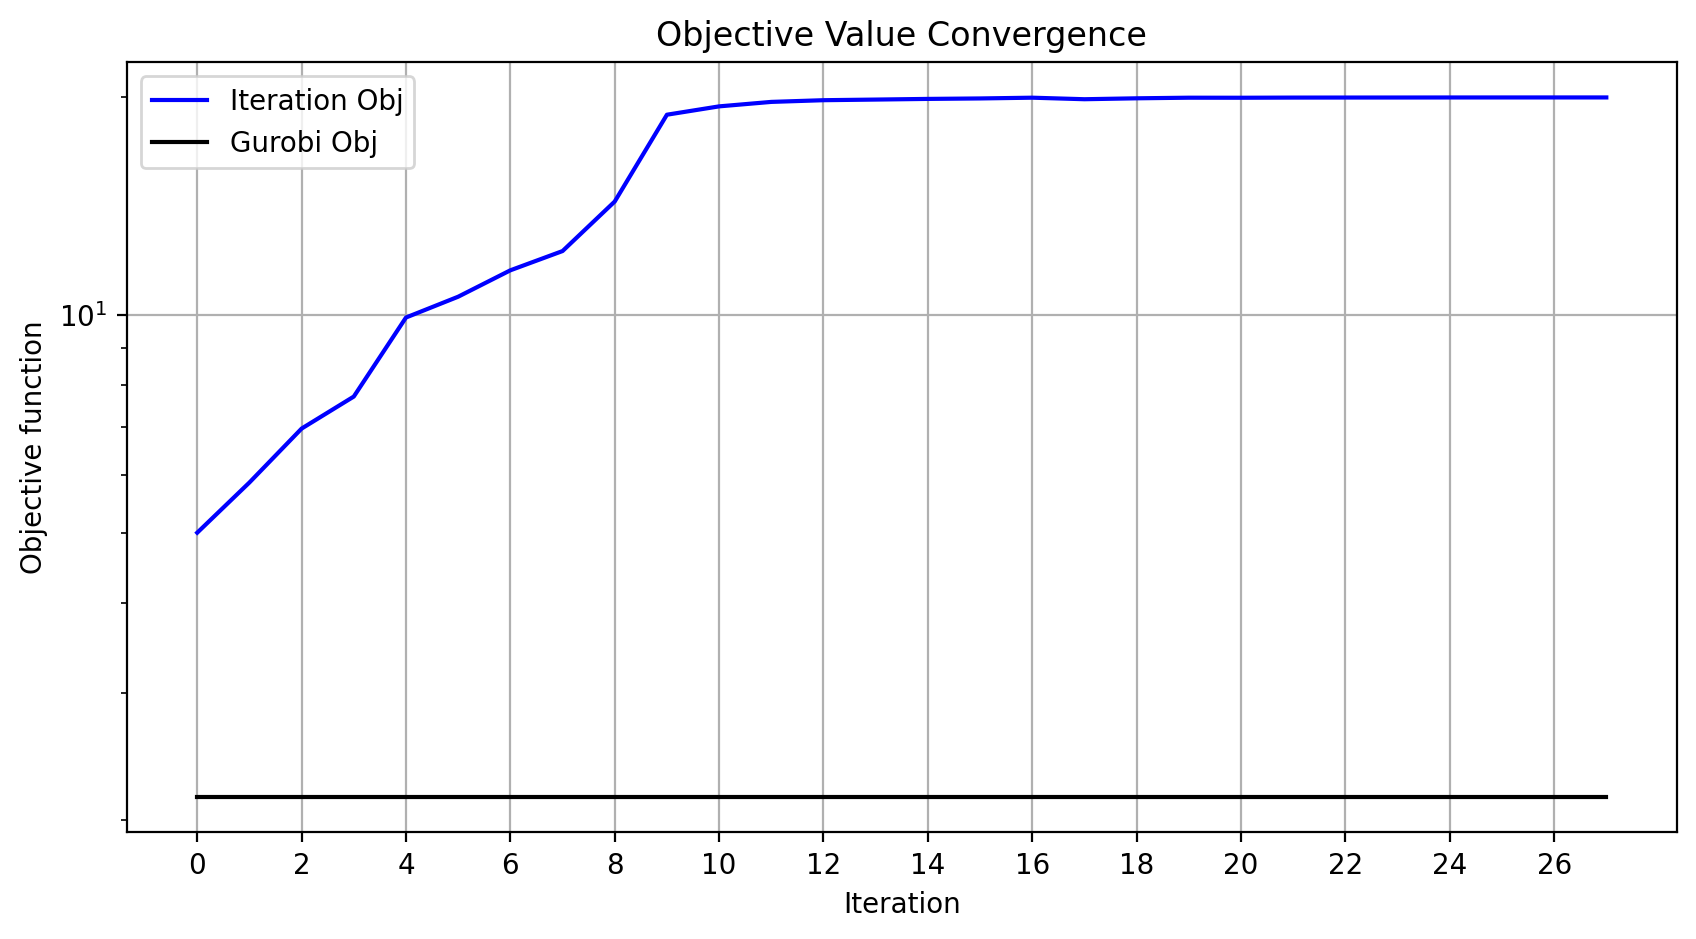

In [11]:
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(len(primal_obj)), primal_obj, linestyle='-', color='b', label='Iteration Obj')
plt.plot(range(len(primal_obj)), (grb_sol)*np.ones(len(primal_obj)), linestyle='-', color='k', label='Gurobi Obj')
plt.xlabel('Iteration')
plt.ylabel('Objective function')
plt.yscale('log')
plt.xticks(range(0,len(primal_obj),2))
plt.title('Objective Value Convergence')
plt.grid(True)
plt.legend()
# plt.savefig(f'FBA-ObjFunVal.png')
plt.show()

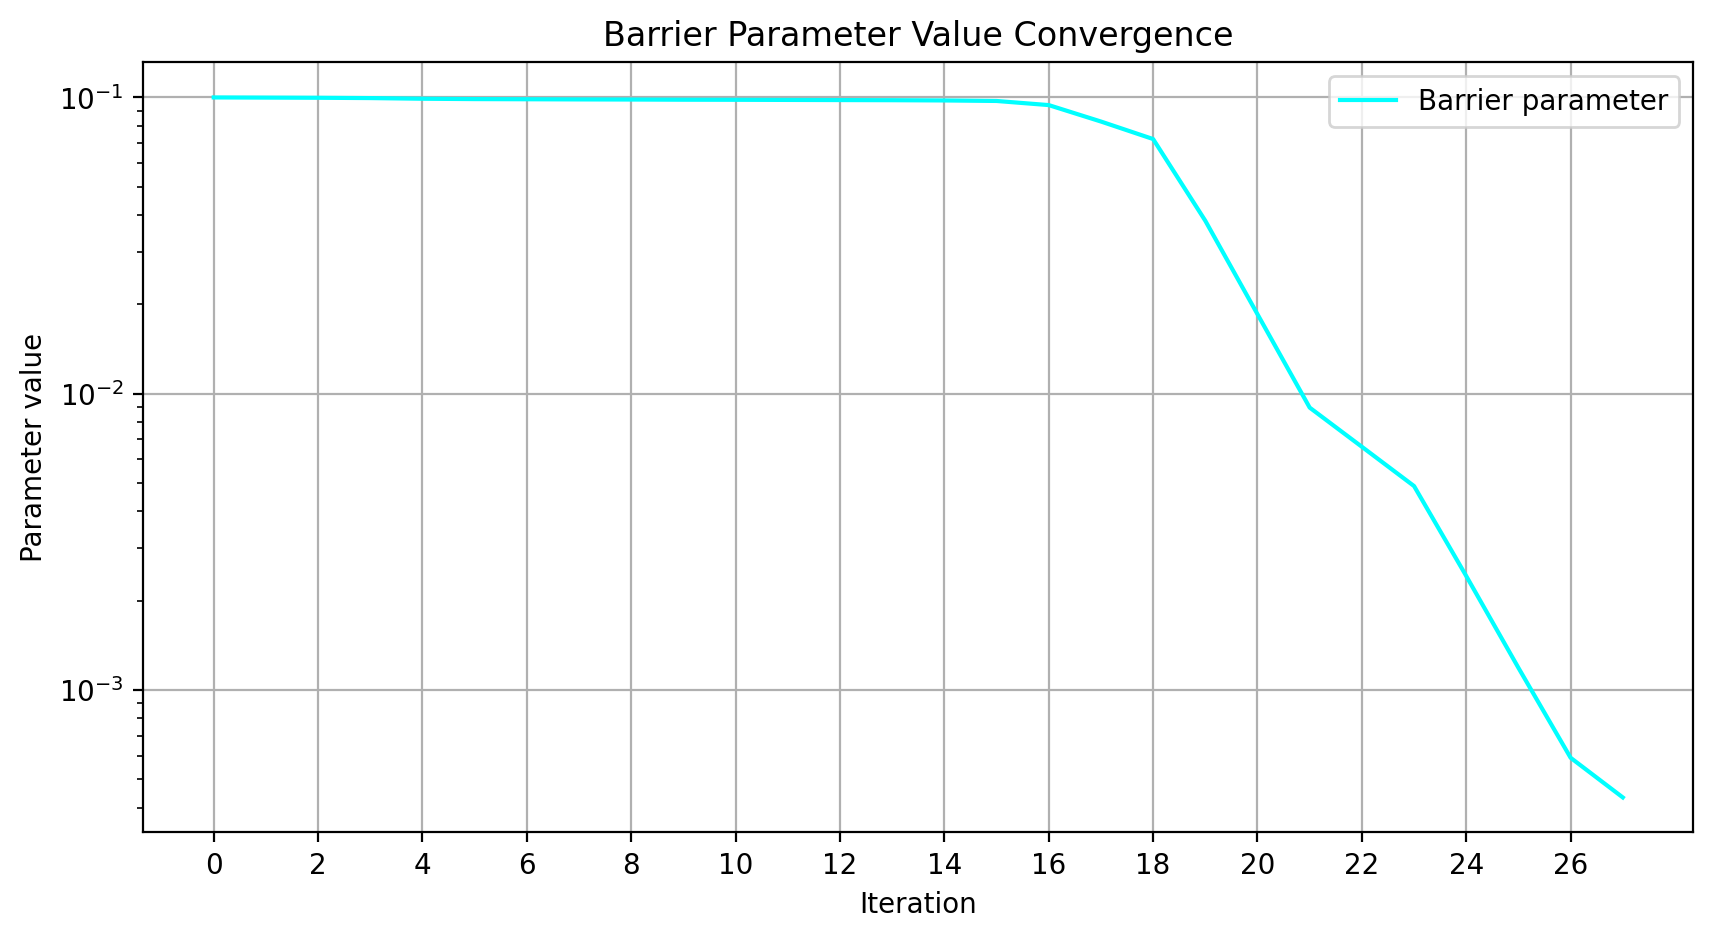

In [12]:
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(len(mu_rec)), mu_rec, linestyle='-', color='cyan', label='Barrier parameter')
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.yscale('log')
plt.xticks(range(0,len(primal_obj),2))
plt.title('Barrier Parameter Value Convergence')
plt.grid(True)
plt.legend()
# plt.savefig(f'BarrierVal.png')
plt.show()

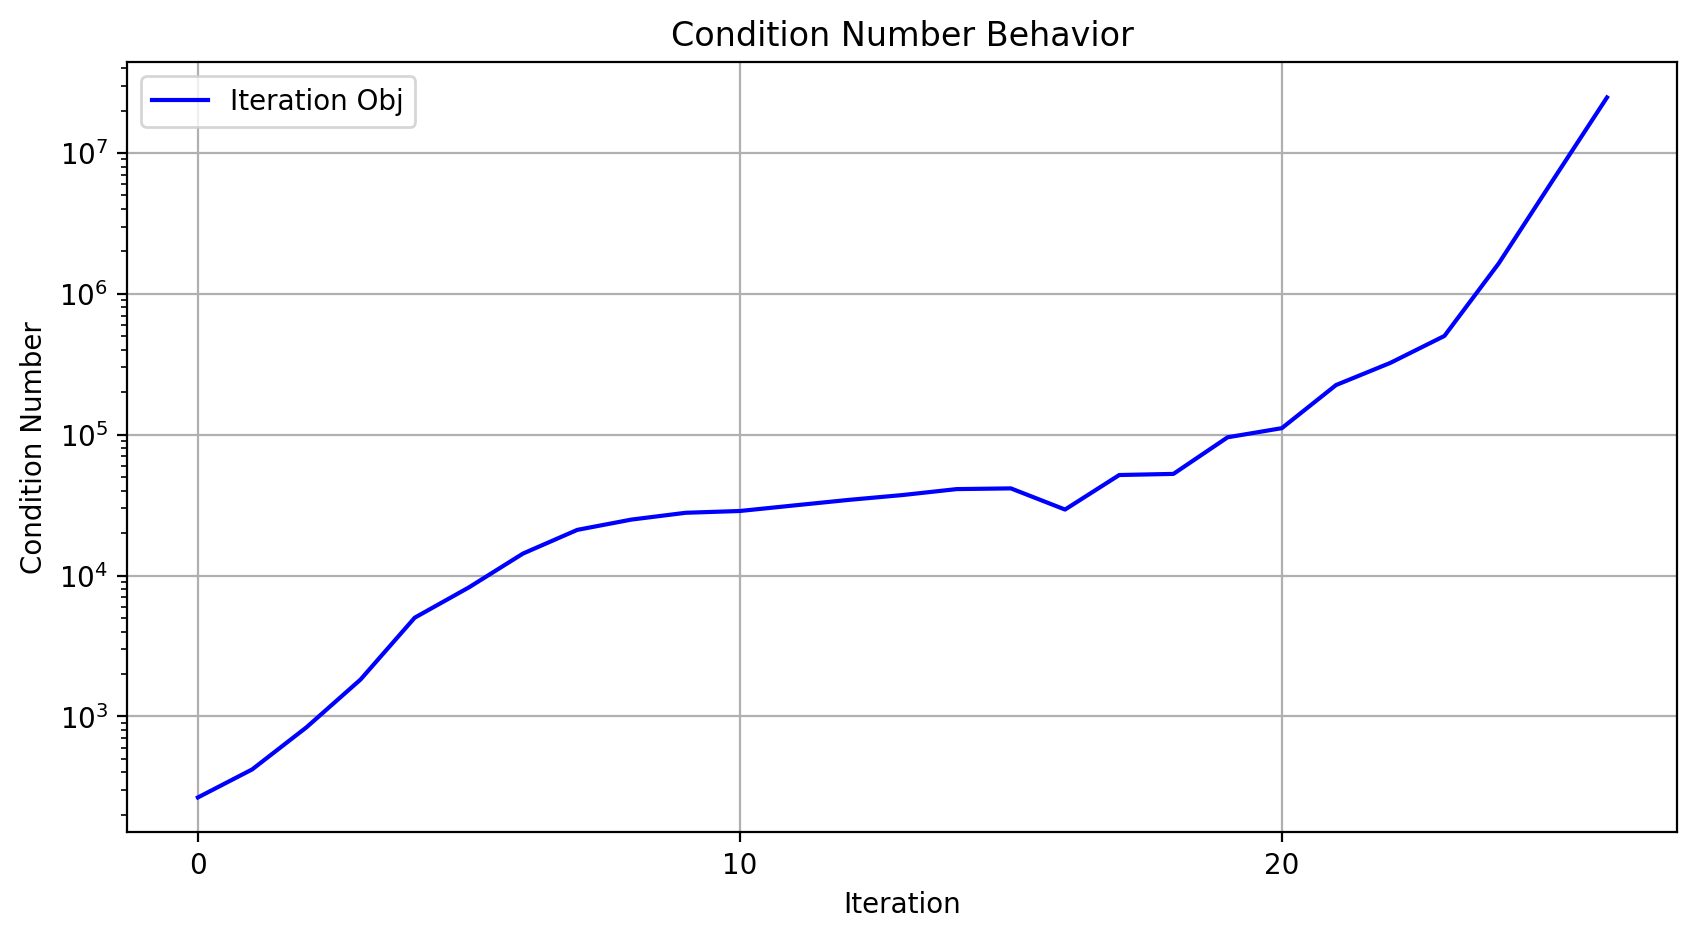

In [13]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(len(cond)), cond, linestyle='-', color='b', label='Iteration Obj')
plt.xlabel('Iteration')
plt.ylabel('Condition Number')
plt.yscale('log')
plt.xticks(range(0,len(cond),10))
plt.title('Condition Number Behavior')
plt.grid(True)
plt.legend()
# plt.savefig(f'.png')
plt.show()

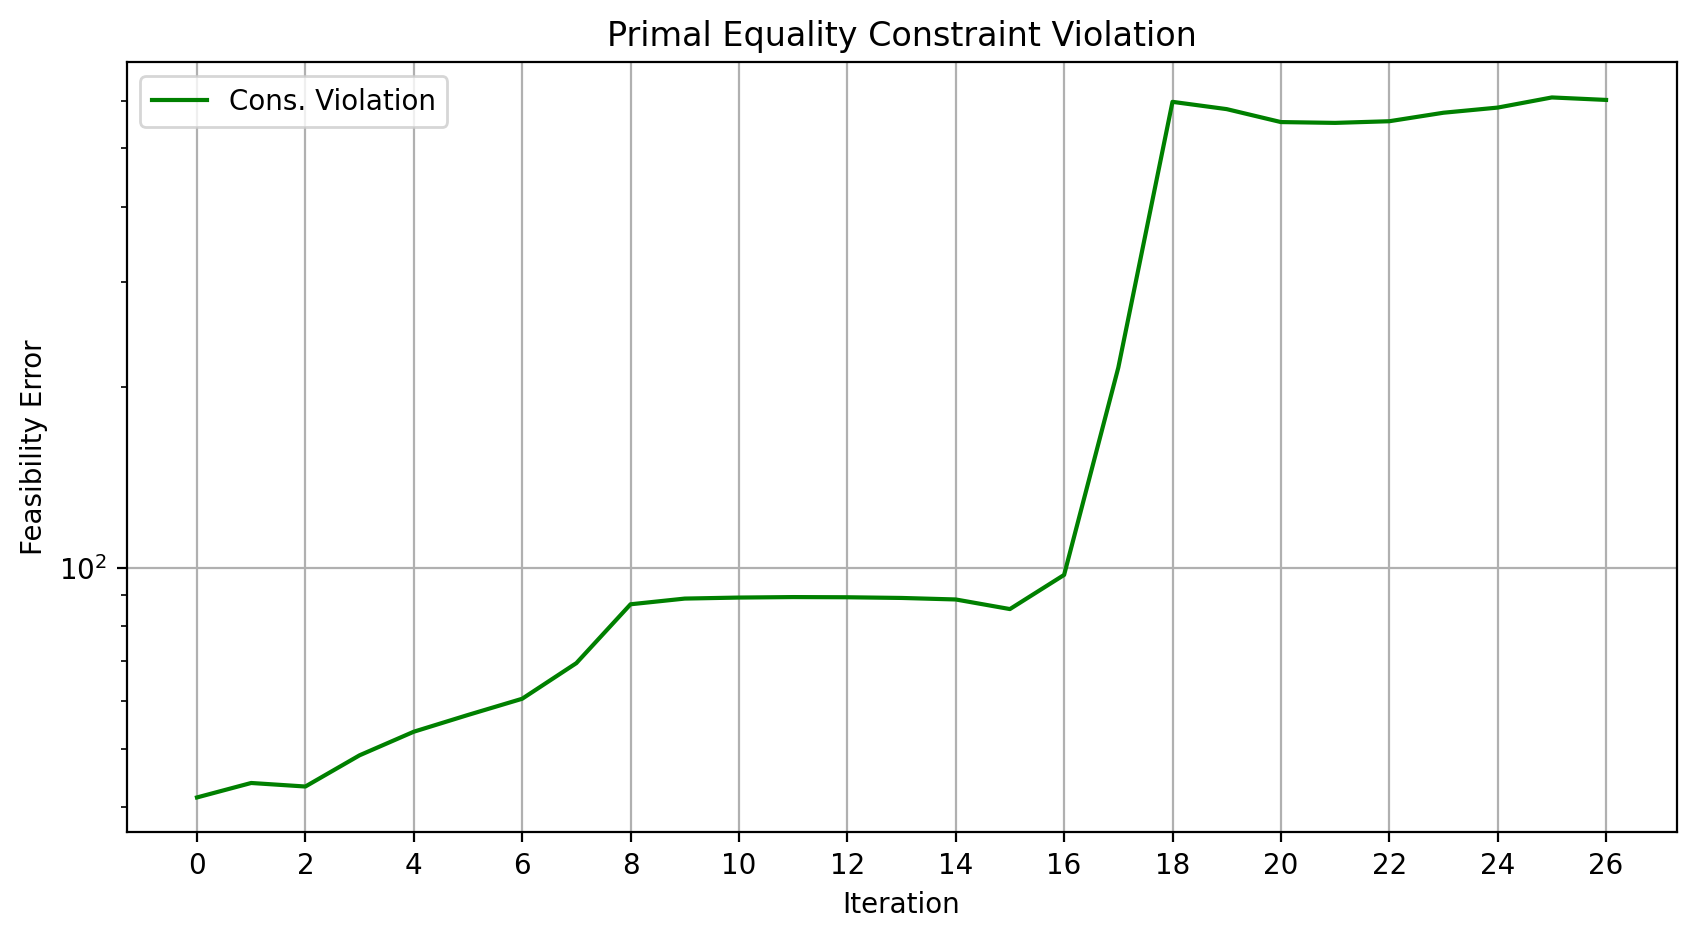

In [14]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(len(primal_viol)), primal_viol, linestyle='-', color='g', label='Cons. Violation')
plt.xlabel('Iteration')
plt.ylabel('Feasibility Error')
plt.yscale('log')
plt.xticks(range(0,len(primal_obj),2))
plt.title('Primal Equality Constraint Violation')
plt.grid(True)
plt.legend()
# plt.savefig(f'PrimalFeasibilty.png')
plt.show()

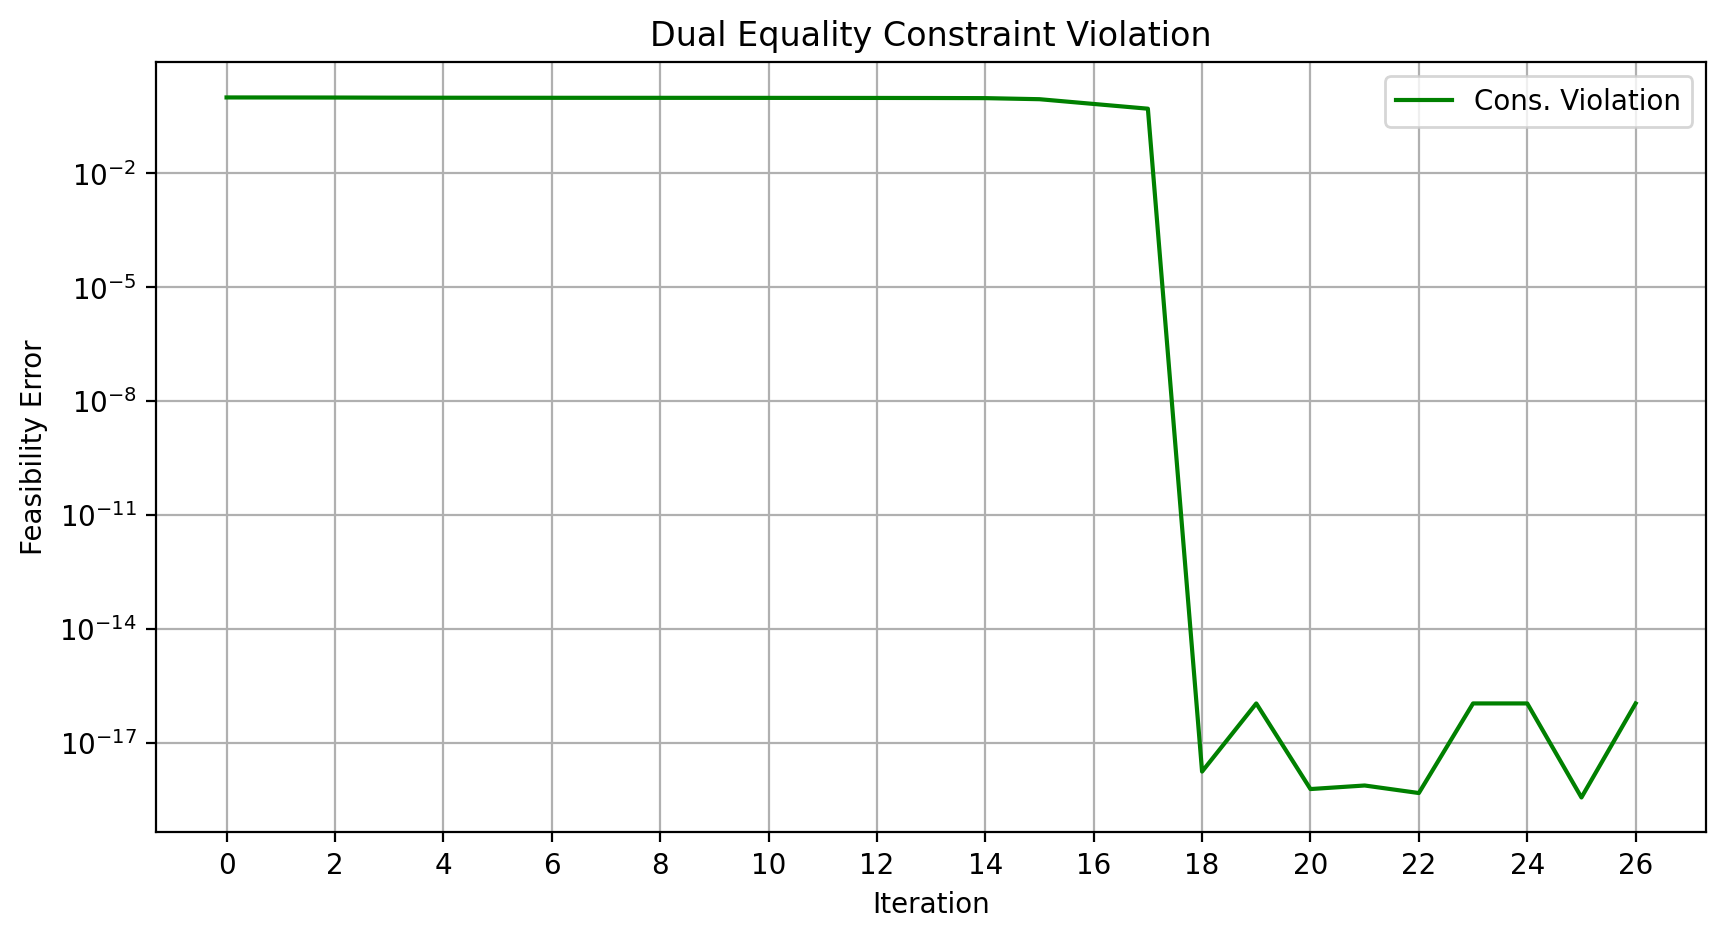

In [15]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(len(dual_viol)), dual_viol, linestyle='-', color='g', label='Cons. Violation')
plt.xlabel('Iteration')
plt.ylabel('Feasibility Error')
plt.yscale('log')
plt.xticks(range(0,len(primal_obj),2))
plt.title('Dual Equality Constraint Violation')
plt.grid(True)
plt.legend()
# plt.savefig(f'DualFeasibility.png')
plt.show()

DEBUG: Found 27 IPM iterations.
DEBUG: Found 2727 total IR steps.
DEBUG: First IPM iter residuals count: 101


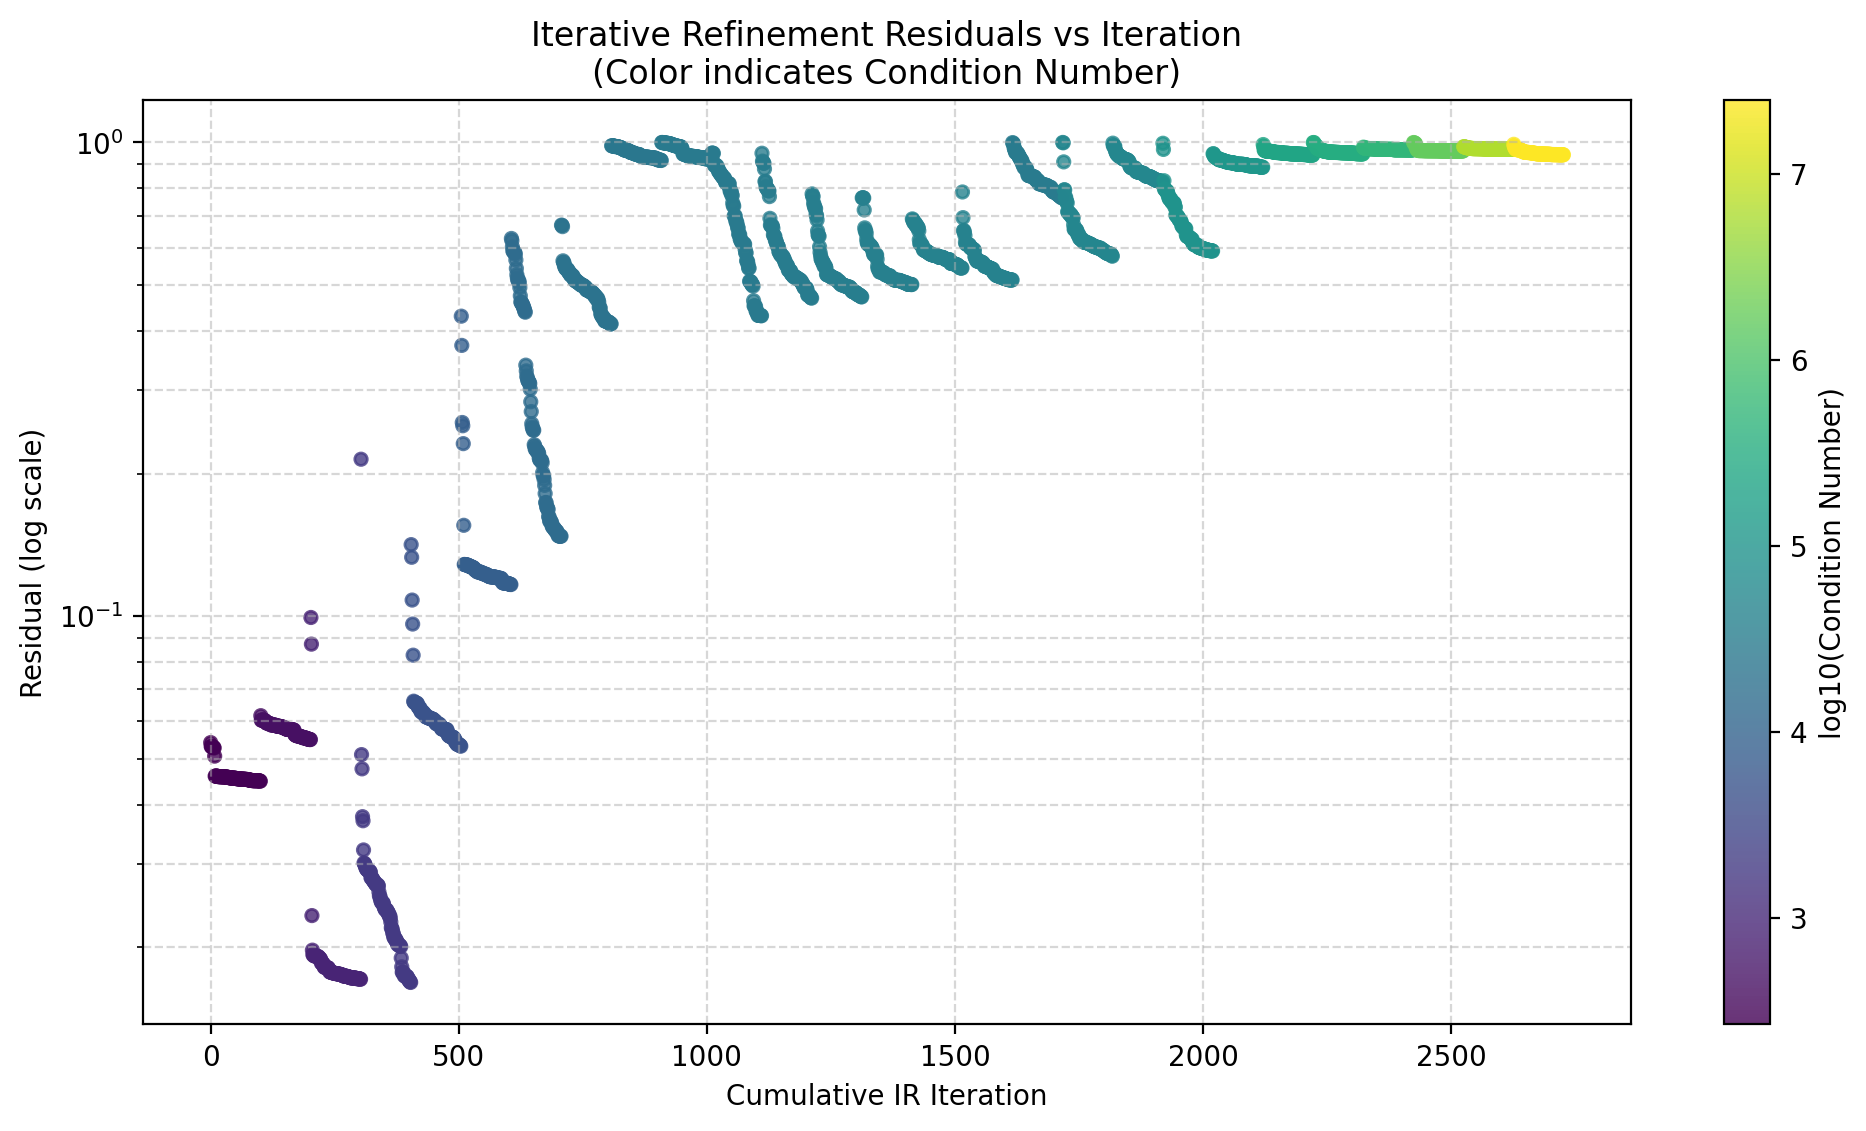

In [16]:
# ------------------------------------------------------------------------------------------------
# NEW CELL: Plot IR Residuals vs Iteration (colored by Condition Number)
# ------------------------------------------------------------------------------------------------

# Flatten the IR data
all_residuals = []
all_conds = []
global_ir_steps = []
step_counter = 0

for data in ir_data:
    residuals = data['residuals']
    cond_num = data['condition_number']
    
    for r in residuals:
        all_residuals.append(r)
        all_conds.append(cond_num)
        global_ir_steps.append(step_counter)
        step_counter += 1

print(f"DEBUG: Found {len(ir_data)} IPM iterations.")
print(f"DEBUG: Found {len(all_residuals)} total IR steps.")
if len(ir_data) > 0:
    print(f"DEBUG: First IPM iter residuals count: {len(ir_data[0]['residuals'])}")

# Create the scatter plot
plt.figure(figsize=(12, 6))
sc = plt.scatter(global_ir_steps, all_residuals, c=np.log10(all_conds), cmap='viridis', s=20, alpha=0.8)
plt.yscale('log')
plt.colorbar(sc, label='log10(Condition Number)')
plt.xlabel('Cumulative IR Iteration')
plt.ylabel('Residual (log scale)')
plt.title('Iterative Refinement Residuals vs Iteration\n(Color indicates Condition Number)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()